In [ ]:
import torch
from torch.nn import functional as F
from matplotlib import pyplot as plt
import numpy as np

def generate_dalex_weights(shape, pressure):
   # Generates random weighting vector 'w'
   # High pressure = sparse, spiky weights (Lexicase behavior)
   noise = torch.randn(shape) * pressure # mean 0, std = pressure

   # Softmax over the noise
   weights = F.softmax(noise, dim=-1) # shape remains after softmaxxing over the last dimension
   return weights * weights.size(-1) # Normalize so mean is 1.0 (keeping scale consistent)

In [49]:
colors = [
   "red",
   "orange",
   "yellow",
   "green",
   "blue",
   "purple",
]

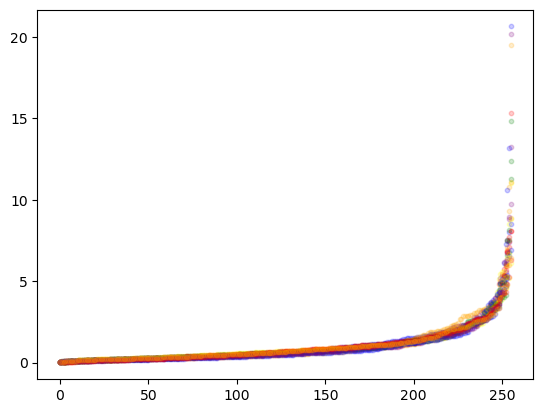

In [73]:
w = generate_dalex_weights((20,256), 1)
for i in range(w.shape[0]):
   plt.scatter(np.arange(256), np.sort(w[i]), c=colors[i % 6], alpha=0.2, s=10)